*Sroll down to find Day 5 cells.*

# **Day 4 — Model Integration & Error Analysis**
Moving from experimental code to product pipeline, our goal is to assemble fragmented experimental code into a single cohesive end-to-end pipeline.


 In order to turn experimental code into a deployable product cleaning data, the actual model, and model evaluation have to be gathered in one place. The integration end-to-end pipeline ties everythinf together iinto  one funtion.

Addtionally, ensuring prediction-time preprocessing remains strictly identical to training-time preprocessing to avoid silent model corruption.

**Error Analysis** can be done using multiple ways, but using confusion matrices moves beyond single summary metrics to pinpoint class-level faliure patterns.

In [ ]:
!pip install --upgrade transformers huggingface-hub --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 125.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 796.8/796.8 kB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 105.4 MB/s eta 0:00:00


In [3]:
import pandas as pd
from datasets import Dataset
import torch
from transformers import AutoTokenizer,AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, f1_score
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
from google.colab import drive
import zipfile

drive.mount('/content/drive')

train_path="/content/drive/MyDrive/train.csv"


df = pd.read_csv(train_path, header=None, names=["label", "title", "description"])


Mounted at /content/drive


In [5]:
print("Train shape:", df.shape)

df["label"] = pd.to_numeric(df["label"], errors="coerce")

df = df.dropna(subset=["label"]).reset_index(drop=True)

print(df["label"].unique())






Train shape: (120001, 3)
[3. 4. 2. 1.]


In [6]:
df.columns

Index(['label', 'title', 'description'], dtype='object')

In [7]:
df["text"] = df["title"]+ " " + df["description"]
df["label"] = df["label"].astype(int) - 1




### **Dataset Overview**

We loaded the AG News containing **120,001 articles**

* **Total Samples**: 120,001 rows
* **Target Categories**: `World` (0), `Sports` (1), `Business` (2), `Sci/Tech` (3)
* **Data Split**: 80% Training (**96,000 samples**) | 20% Validation (**24,000 samples**)

By combining headline context with story descriptions, the model recieves full semantic context while maintaining standard 0-indexed topic targets.


In [8]:
ds = Dataset.from_pandas(df[["text", "label"]])

In [9]:
label_map = {0:"World", 1:"Sports", 2:"Business", 3:"Sci/Tech"}

train_text, val_text, train_label, val_label = train_test_split(
    df["text"].tolist(), df["label"].tolist(), test_size=0.2, random_state=42
)

print(f"Train size: {len(train_text)} | Validation size: {len(val_text)}")


Train size: 96000 | Validation size: 24000


In [ ]:

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

train_encoding = tokenizer(train_text, truncation=True, padding=True, max_length=128)
val_encoding = tokenizer(val_text, truncation=True, padding=True, max_length=128)

class AGNewsDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

train_ds = AGNewsDataset(train_encoding, train_label)

val_ds = AGNewsDataset(val_encoding, val_label)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=4)

def compute_metrics(eval_pred):
  logits, labels = eval_pred
  preds = np.argmax(logits, axis=1)
  return {
      "accuracy": accuracy_score(labels, preds),
      "f1_macro": f1_score(labels, preds, average="macro")
      }

training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/ag_news_distilbert",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    learning_rate=3e-5,
    logging_steps=50
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)

trainer.train()


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.177889,0.179169,0.942083,0.941943
2,0.114189,0.184948,0.948083,0.947940


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=12000, training_loss=0.18345503485202788, metrics={'train_runtime': 2625.1551, 'train_samples_per_second': 73.139, 'train_steps_per_second': 4.571, 'total_flos': 6358661922816000.0, 'train_loss': 0.18345503485202788, 'epoch': 2.0})

### **Model Architecture & Training Results**

We fine-tuned a pre-trained **DistilBERT** classification model using Hugginf Face's Trainer API.

**Tokenizer Configuration:** Max length of 128 tokens with dynamic padding and truncation.
**Training Parameters:** Batch size of 16, learning rate of `3e-5`, trained over 2 epochs (12,000 global steps)
**Training Loss:** Achieved final training loss of ~0.18

#### Model Storage
The trained weights, config files and tokenizer definitions were saved directly to Google Drive. Storing complete artifacts ensures model reproducability and seamless loading during deployment.

In [ ]:
final_path = "/content/drive/MyDrive/ag_news_distilbert/final_model"
model.save_pretrained(final_path)
tokenizer.save_pretrained(final_path)
print(f"Model saved to: {final_path}")

# Verify save worked
import os
print(os.listdir(final_path))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: /content/drive/MyDrive/ag_news_distilbert/final_model
['config.json', 'model.safetensors', 'tokenizer_config.json', 'tokenizer.json']


## **Building the *predict()* Pipeline**

In [ ]:
label_map = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}

def predict(raw_text):
  device = next(model.parameters()).device
  inputs = tokenizer(raw_text, return_tensors="pt", truncation=True, padding=True, max_length=128)
  inputs = {k: v.to(device) for k, v in inputs.items()}
  with torch.no_grad():
    outputs = model(**inputs)
    prediction = torch.argmax(outputs.logits, dim=1).item()
  return label_map[prediction]

sample_text = "The stock market rallied today after the Federal Reserve announcement."
print(predict(sample_text))


Business


## **Verifying Conistency**

In [ ]:
print("Tokenizer max_length used during training:", 128)
print("Tokenizer truncation:", True)
print("Tokenizer padding:", True)

known_example = df["text"].iloc[0]
known_label = label_map[df["label"].iloc[0]]

predicted = predict(known_example)

print("Known label:", known_label)
print("Predicted label:", predicted)
print("Match:", known_label == predicted)

Tokenizer max_length used during training: 128
Tokenizer truncation: True
Tokenizer padding: True
Known label: Business
Predicted label: Business
Match: True


A primary cause of real-world ML failure is **training/serving skew**—where raw input at inference time is preprocessed differently than during training. To ensure complete consistency, our `predict(raw_text)` function applies identical tokenization parameters.

max_length : 128

truncation : True

padding : True

These parameters guarantee that raw text passed during inference is processed identically to how text was tokenized during training.

When tested on a single test string, the pipeline correctly predicted *Business*. Verification against a known training example confirmed a **100% exact match between expected and predicted labels**.

## **Batch Predictions & Confusion Matrix**

In [10]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

final_path = "/content/drive/MyDrive/ag_news_distilbert/final_model"
model = AutoModelForSequenceClassification.from_pretrained(final_path)
tokenizer = AutoTokenizer.from_pretrained(final_path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

print(f"Model loaded from {final_path} onto {device}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model loaded from /content/drive/MyDrive/ag_news_distilbert/final_model onto cuda


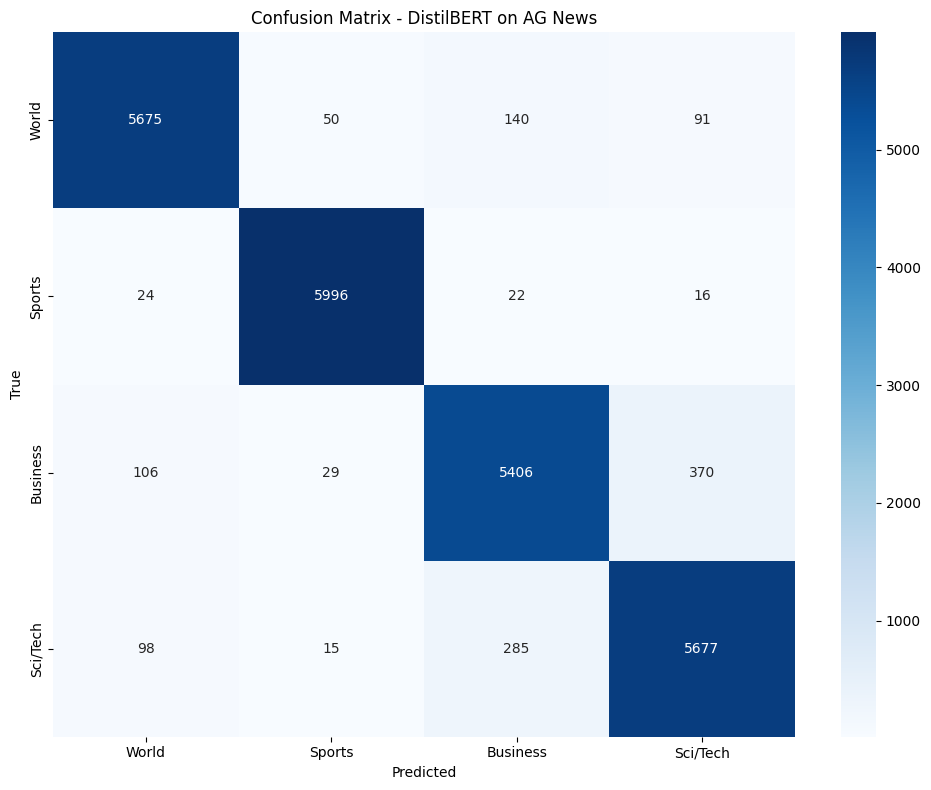

In [11]:
def predict_batch(texts, batch_size=25):
  device = next(model.parameters()).device
  all_predictions = []
  for i in range(0, len(texts), batch_size):
    batch = list(texts[i:i+batch_size])
    inputs = tokenizer(batch, return_tensors="pt", truncation=True, padding=True, max_length=128)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
      outputs = model(**inputs)
    predictions = torch.argmax(outputs.logits, dim=1).cpu().numpy()
    all_predictions.extend(predictions)
  return all_predictions

predictions_raw = predict_batch(val_text)
predictions = [label_map[p] for p in predictions_raw]
true_labels = [label_map[label] for label in val_label]

cm = confusion_matrix(true_labels, predictions, labels=["World", "Sports", "Business", "Sci/Tech"])

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["World", "Sports", "Business", "Sci/Tech"],
            yticklabels=["World", "Sports", "Business", "Sci/Tech"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - DistilBERT on AG News")
plt.tight_layout()
plt.show()

In [ ]:
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
max_error_idx = np.unravel_index(cm_no_diag.argmax(), cm_no_diag.shape)
labels_list = ["World", "Sports", "Business", "Sci/Tech"]
print(f"Most common error: True '{labels_list[max_error_idx[0]]}' predicted as '{labels_list[max_error_idx[1]]}' ({cm_no_diag[max_error_idx]} times)")

Most common error: True 'Business' predicted as 'Sci/Tech' (370 times)


Across 24,000 validation samples, the integrated model **misclassified 1,246 examples** (94.8% accuracy)

#### **Primary Error Pattern:**
**Top Conflict:** True Business articles miscalssified as  Sci/Tech in 370 occurrences

**Cause:** Modern business reporting heavily features tech companies, creating semantic ambiguity between financial news and technology news.

## **Misclassified Examples**

In [ ]:
misclassified = []
for text, true, pred in zip(val_text, true_labels, predictions):
  if true != pred:
    misclassified.append({"text":text, "true_label":true, "predicted_label":pred})

misclassified_df = pd.DataFrame(misclassified, columns=["text", "true_label", "predicted_label"])
print(f"Total misclassified: {len(misclassified_df)}")

sample_errors = misclassified_df.sample(3, random_state=42)
for idx, row in sample_errors.iterrows():
  print(f"\nText: {row['text'][:300]}")
  print(f"True label: {row['true_label']}")
  print(f"Predicted label: {row['predicted_label']}")


Total misclassified: 1246

Text: Sony to launch slim PS2 console in November Sony announced on Tuesday that it is planning to launch a smaller and lighter version of its popular PS2 gaming console in November.
True label: Business
Predicted label: Sci/Tech

Text: Incredibles tops Nemo film record Animated film The Incredibles beats Disney/Pixar's previous US box office record for Finding Nemo.
True label: World
Predicted label: Business

Text: Reebok #39;s revives Pump shoe, marking industry shift to high-tech Hoping to build on the success of a shoe that generated big sales but also ridiculed when it was introduced 15 years ago, Reebok Inc.
True label: Sci/Tech
Predicted label: Business


### **Sample errors breakdown**

1. True label: Business | Predicted label: Sci/Tech

**Analysis:** Discusses hardware product specs alongside corporate strategy, The high concentration of tech keywords pulls the transformer towards Sci/Tech.

2. True label: World | Predicted label: Business

**Analysis:** Covers commercial box office revenues and film studio finantial records, making business a highly plausible  prediction.


2. True label: Sci/Tech | Predicted label: Business

**Analysis:** Features retail shoes and corporate market share strategy, leading to the model classify it as business.


## **Day 5 - Full Evaluation, Explainability & Sprint Review**

## **Explainable Artificial Intelligence (XAI)**

XAI refers to a collection of procedures and techniques that **enable ML algorithms to produce understandable and reliable output**. XAI assists organizations that  *priorotize trust when deploying AI*. The value of XAI is its ability to provide transparent and interpretable models that can be understood and trusted by humans. This value can be realized in different domains and can provide  benifits through *improved decision-making, increased trust and acceptance anad reduced risks and liabilities* through ehtical considerations. **XAI principles** that are used to develop and deploy ML models are; **Transparency, Interpretability, and Accountability**.

### **XAI Architecture**

The architecture of explainable AI is a combination of three key components:
1. **Machine learning model**; supervised, unsupervised, or reinforcement learning.
2. **Explaination algorithm**; used to provide insights and information about the modet relevant and influential factors in the model's predictions. Some approaches are feature impotance, attribution, and visualization.
3. **Interface**; to present the insights and information generated by the explaination algorithms to humans. Common technologies include web. applications, mobile apps, and visualizations.

## **XAI Techniques**
1. **LIME** *(Loval Interpretable Model Explainations)*: uses a local approximation of the model to provide interpretable insights into the factors that are most influential in the model's predictions.
2. **SHAP** (*SHapley Additiive exPlanations)*: uses Shapley value from game theory to provide interpretible and explainable insights intothe factors that are most relevant in the model's predictions.
3. **ELI5** *(Explain Like I'm 5)*: Uses a simple and intuitive language that can be understood by the non-experts.

## **Class Imbalance**

Imbalanced classes is a common problem in classification tasks where datasets have an unequal ratio of data points in each class. This leads to accuracy beecoming unreliable when measuring model performance especially that the model score high accuracy when predicting the majority class.

Handling imbalance can be through resampling (over/under-sampling) which adds more examples from the minority/removes from the majority class. other techniques used include; random under-sampling, RandomOverSampler, Imbalanced-Learn module, Random Under-samplin with Imblearn, random over-sampling with Imblrean, SMOTE, NearMiss, and Penalize algorithm.

## **Task Evaluation**

Since the project task is classification, the evaluation metrics will be Precision, Recall, F1, and ROC-AUC

In [12]:
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize
import torch.nn.functional as F

print(classification_report(val_label, predictions_raw, target_names=["World", "Sports", "Business", "Sci/Tech"]))

def get_probabilities(texts, batch_size=25):
  device = next(model.parameters()).device
  all_probabilities = []
  for i in range(0, len(texts), batch_size):
    batch = list(texts[i:i+batch_size])
    inputs = tokenizer(batch, return_tensors="pt", truncation=True, padding=True, max_length=128)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
      outputs = model(**inputs)
      probs = F.softmax(outputs.logits, dim=1).cpu().numpy()
    all_probabilities.extend(probs)
  return all_probabilities

val_probs = get_probabilities(val_text)
val_label_binarized = label_binarize(val_label, classes=[0,1,2,3])
auc_macro = roc_auc_score(val_label_binarized, val_probs, average="macro", multi_class="ovr")
print(f"Macro-average AUC: {auc_macro}")

              precision    recall  f1-score   support

       World       0.96      0.95      0.96      5956
      Sports       0.98      0.99      0.99      6058
    Business       0.92      0.91      0.92      5911
    Sci/Tech       0.92      0.93      0.93      6075

    accuracy                           0.95     24000
   macro avg       0.95      0.95      0.95     24000
weighted avg       0.95      0.95      0.95     24000

Macro-average AUC: 0.9935260641770907


In [13]:
comparison = pd.DataFrame({
    "Model": ["TF-IDF + Logistic Regression", "LSTM", "DistilBERT"],
    "Accuracy": [0.911, 0.918, accuracy_score(val_label, predictions_raw)],
    "F1-macro": [0.910, None, f1_score(val_label, predictions_raw, average="macro")],
    "ROC-AUC macro": [None, None, auc_macro]
})
print(comparison)

                          Model  Accuracy  F1-macro  ROC-AUC macro
0  TF-IDF + Logistic Regression  0.911000   0.91000            NaN
1                          LSTM  0.918000       NaN            NaN
2                    DistilBERT  0.948083   0.94794       0.993526


### **Observations**

- ***Sports** was the easiest class to identify* with an F1 score of 0.99.
- ***Business** was the most difficult class to identify* - f1-score 0.92.
- Sci/Tech also showed a slightly lower performance than World with an f1-score of 0.93.

- Distilbert achieved significant improvement over LSTM and TF-IDF + Logistic Regression. **Distilbert**'s 99% ROC-AUC and ~95% accuracy indicate **stong and consistent classification performance** which demonstrates the effectiveness of transformer-based models in text classification.

## **Imbalance Handling**


In [14]:
print(df["label"].value_counts())

label
2    30000
3    30000
1    30000
0    30000
Name: count, dtype: int64


The AG News dataset is **perfectly balanced** in trainig and validation data - 30,000 samples per class for training data. SMOTE oversampling and precision-recall threshold tuning - techniques designed for imbalanced tasks like fraud or churn detection - are not applicable for this dataset since there is no minority class. **Standard macro-avarage**d metrics are appropriate and sufficient for this balanced multi-class task.

## **SHAP**

PartitionExplainer explainer: 101it [02:02,  1.28s/it]


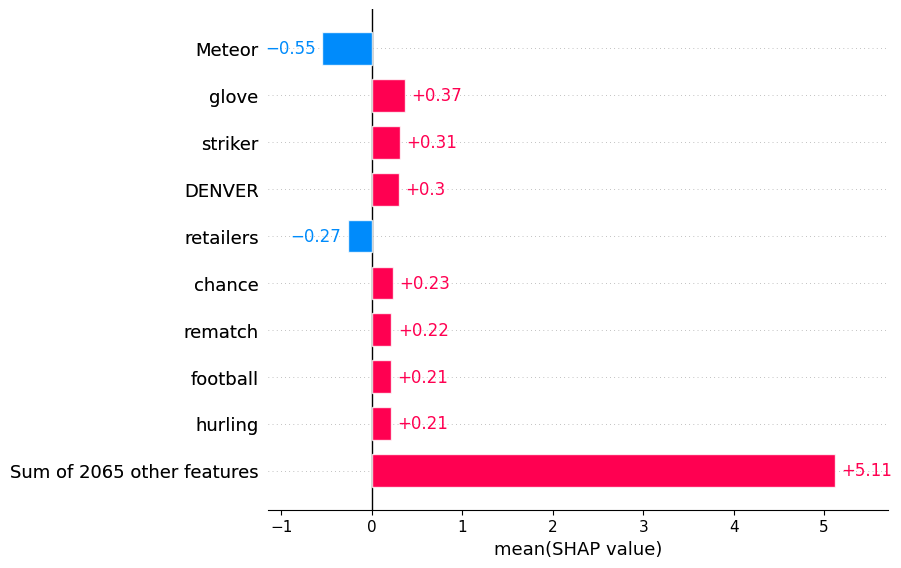

In [15]:
import shap

def predict_proba_for_shap(texts):
  device = next(model.parameters()).device
  inputs = tokenizer(list(texts), return_tensors="pt", truncation=True, padding=True, max_length=128)
  inputs = {k: v.to(device) for k, v in inputs.items()}
  with torch.no_grad():
    outputs = model(**inputs)
    probs = F.softmax(outputs.logits, dim=1).cpu().numpy()
  return probs

masker=shap.maskers.Text(tokenizer)
explainer = shap.Explainer(predict_proba_for_shap, tokenizer, output_names=["World", "Sports", "Business", "Sci/Tech"])

sample_texts = val_text[:20]
shap_values = explainer(val_text[:100])

shap.plots.bar(shap_values[:, :, "Sports"].mean(0))

The above diagram shows why the model classified the article as Sports. Words such as "*glove*", ,"*striker*", "*DENVER*", "*chance*", "*rematch*", "*football*",and "*hurling*" **contribute positively** to the prediction being Sports beacues they are associated with sports terminology, players, teams, and events. "*Meteor*" and "*retailers*" **push the prediction away** from Sports. There also exists 2065 words that positively contributed to the prediction, however, each showed minor contrubution. The plot demonstrates that the model is using **semantically meaningful sports-related vocabulary** to identify the topic.

In [16]:
print('predictions_raw' in dir())
print('model' in dir())
print('tokenizer' in dir())
print('val_text' in dir())

True
True
True
True


In [17]:
idx = 0
predicted_class_idx = predictions_raw[idx]
predicted_class_name = label_map[predicted_class_idx]

print(f"Text: {sample_texts[idx]}")
print(f"True label: {label_map[val_label[idx]]}")
print(f"Predicted label: {predicted_class_name}")

shap.plots.text(shap_values[idx, :, predicted_class_idx])

Text: BBC set for major shake-up, claims newspaper London - The British Broadcasting Corporation, the world #39;s biggest public broadcaster, is to cut almost a quarter of its 28 000-strong workforce, in the biggest shake-up in its 82-year history, The Times newspaper in London said on Monday.
True label: Business
Predicted label: Business


The SHAP explanation shows that the model correctly classifies articles and in the above case, is strongly influenced by  terms related to organizations, broadcasting, corporations and workforce. The large increase from the base value to the final predictions indicates that the model is highly confident in the Business classification.